In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [30]:
data = pd.read_csv("https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv")
data.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [ ]:
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
x = data.drop(["Survived", "Name"], axis = 1)
y = data["Survived"]
x.head()
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2)

In [ ]:
lr = LogisticRegression()
lr.fit(X=x_train, y=y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
score = lr.score(X=x_test, y=y_test)
score*100

76.96629213483146

In [ ]:
#accuracy score
ac = accuracy_score(y_pred, y_test)
print(ac)
#classification report
cr = classification_report(y_pred, y_test)
print(cr)
#confusion matrix
cm = confusion_matrix(y_pred, y_test)
print(cm)

0.7696629213483146
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       106
           1       0.75      0.65      0.70        72

    accuracy                           0.77       178
   macro avg       0.76      0.75      0.76       178
weighted avg       0.77      0.77      0.77       178

[[90 16]
 [25 47]]


In [ ]:
df = pd.DataFrame(data={"Test":y_test, "Pred": y_pred})

(array([[115.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  63.],
        [106.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  72.]]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <a list of 2 BarContainer objects>)

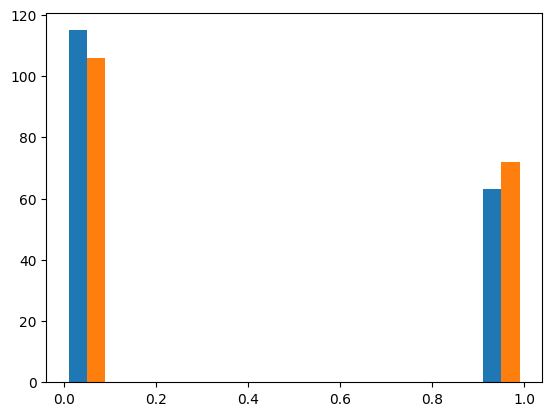

In [ ]:
#plt.hist(df["Test"])
plt.hist([df["Test"],df["Pred"]])
